# Analasing neuroComBat behaivor when imbalance across sites.

In [167]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import structlog
from sklearn.linear_model import LogisticRegression

from uniharmony.combat import NeuroComBat
from uniharmony.datasets import make_multisite_classification


# To only get the necessary info from structlog, we configure it to filter out messages below INFO level.
structlog.configure(wrapper_class=structlog.make_filtering_bound_logger(logging.INFO))
combat = NeuroComBat()
clf = LogisticRegression()

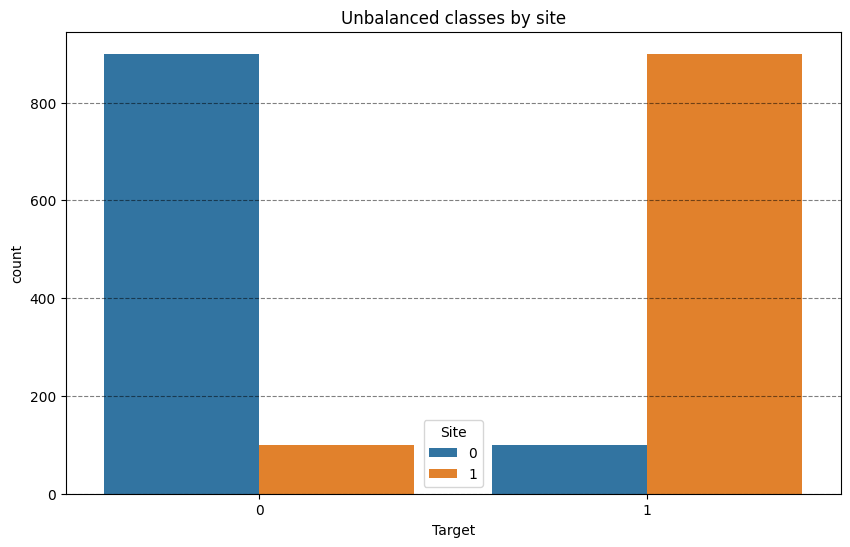

In [168]:
X, y, sites = make_multisite_classification(
    n_classes=2,
    n_samples=2000,
    n_sites=2,
    n_features=2,
    signal_strength=2,
    site_effect_strength=0,
    balance_per_site=[0.1, 0.9],
    site_effect_homogeneous=True,
)
df = pd.DataFrame({"Target": y, "Site": sites})

plt.figure(figsize=[10, 6])
plt.title("Unbalanced classes by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

In [169]:
def plot_decision_boundery(ax, clf):
    """Plot me."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100), np.linspace(ylim[0], ylim[1], 100))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0], colors="black", linewidths=1, alpha=0.7)

0.8465
0.6105


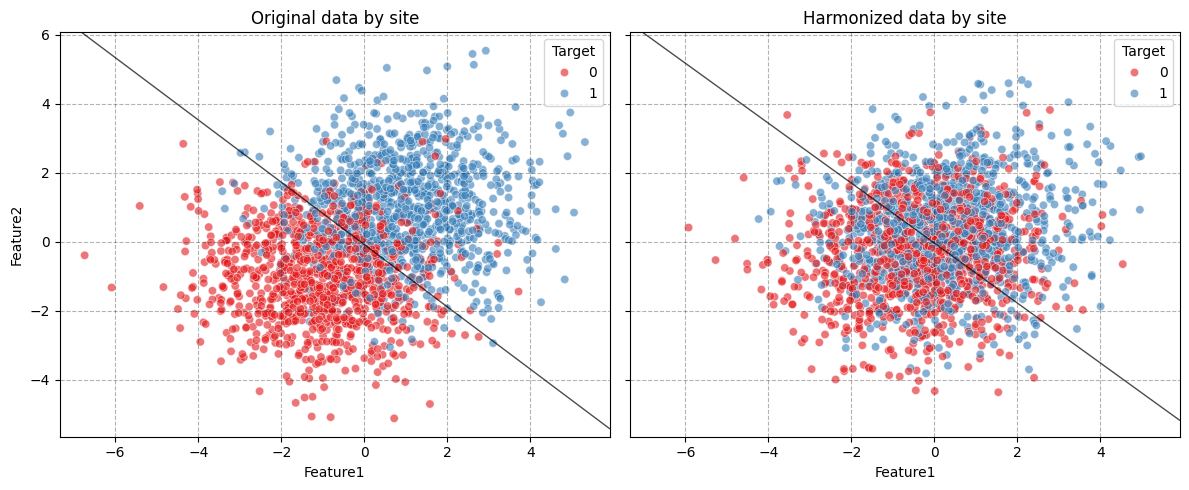

In [182]:
X_harmonized = combat.fit_transform(X, sites)
df_orig = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites
df_orig["Target"] = y
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites
df_harm["Target"] = y
df_harm["Phase"] = "Harmonized"

clf.fit(X, y)
print(clf.score(X, y))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Target", palette="Set1", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(alpha=0.3, color="black", linestyle="--")
plot_decision_boundery(axes[0], clf)
clf.fit(X_harmonized, y)
print(clf.score(X_harmonized, y))
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Target", palette="Set1", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(alpha=0.3, color="black", linestyle="--")
plot_decision_boundery(axes[1], clf)
plt.tight_layout()

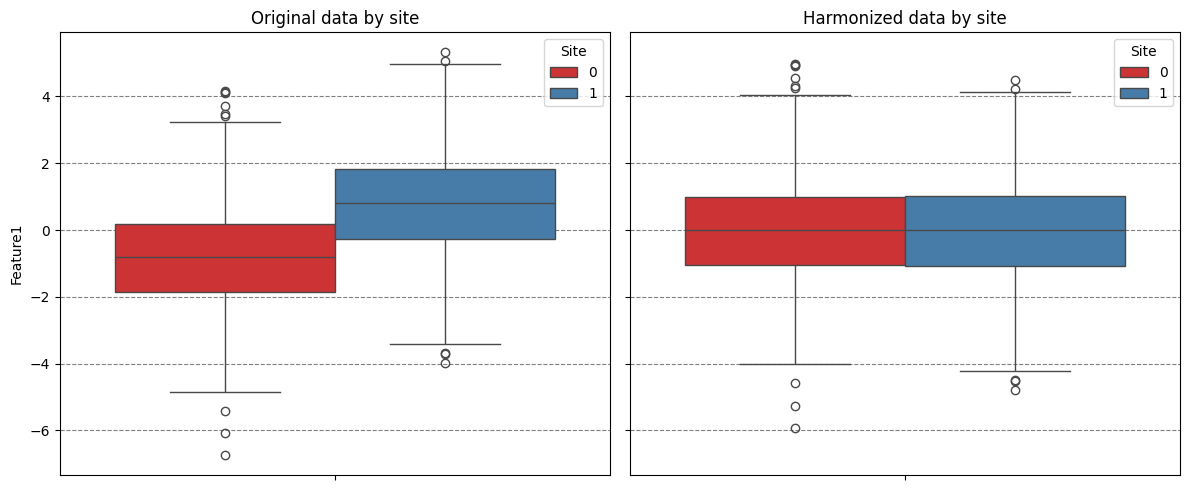

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.boxplot(data=df_orig, y="Feature1", hue="Site", palette="Set1", ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(axis="y", color="black", alpha=0.5, linestyle="--")
sns.boxplot(data=df_harm, y="Feature1", hue="Site", palette="Set1", ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(axis="y", color="black", alpha=0.5, linestyle="--")
plt.tight_layout()

2026-03-27 00:11:50 [warning  ] You specified categorical and/or continuous covariates to be preserved. If you intend to build a machine learning (ML) model,then make sure that you DO *NOT* preserve the ML model's target as covariate. You will be required to provide the covariate also at transform time, and this will produce data leakage. If you are performing a statistical analysis and want to preserve a variable of interest, then it is correct to specify it as covariate.
0.8465
0.842


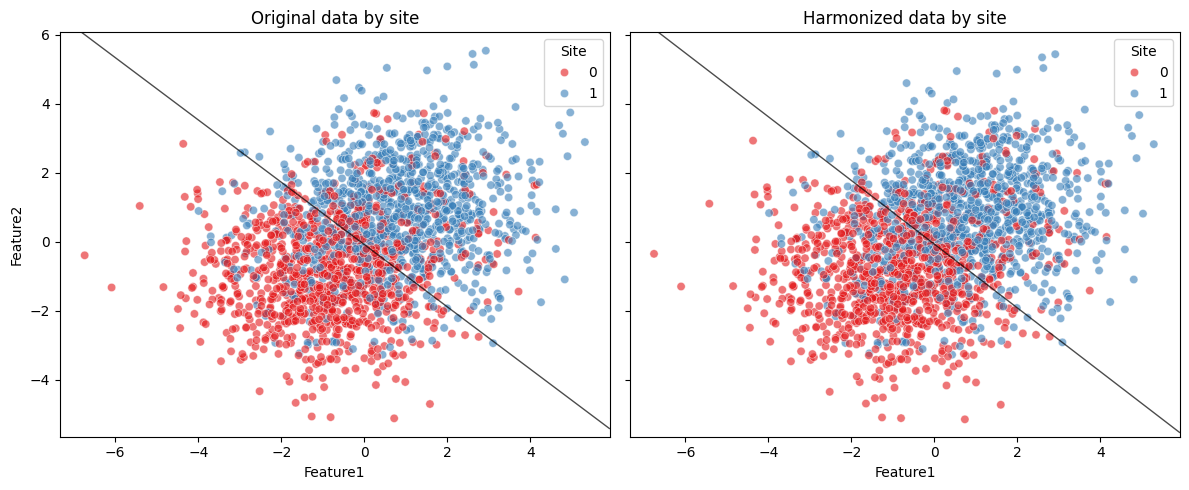

In [172]:
combat = NeuroComBat()
X_harmonized = combat.fit_transform(X, sites, categorical_covariates=y.reshape(-1, 1))
df_orig = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites
df_harm["Phase"] = "Harmonized"
clf.fit(X, y)
print(clf.score(X, y))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Site", palette="Set1", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
plot_decision_boundery(axes[0], clf)

clf.fit(X_harmonized, y)
print(clf.score(X_harmonized, y))
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Site", palette="Set1", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
plot_decision_boundery(axes[1], clf)

plt.tight_layout()

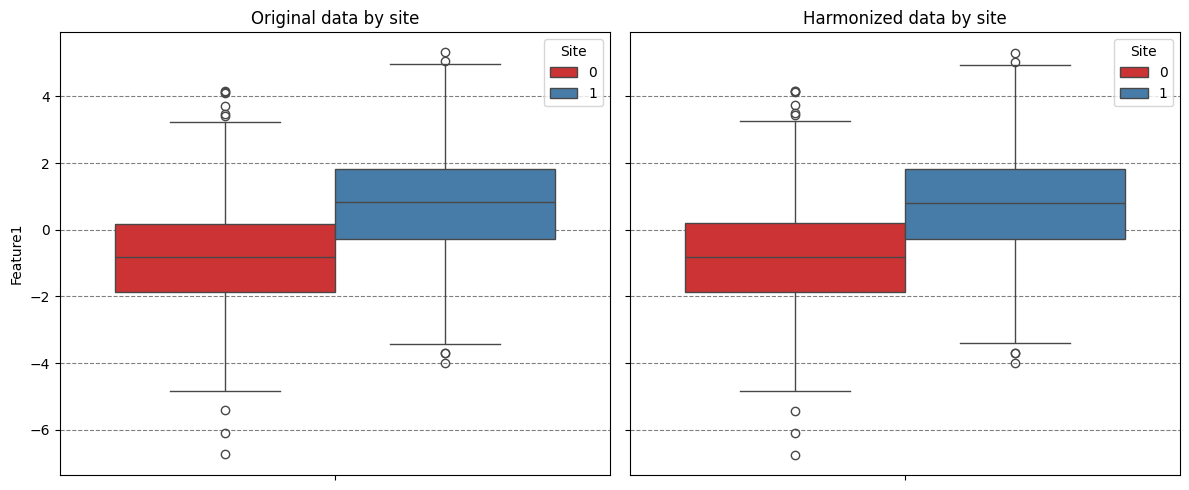

In [173]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.boxplot(data=df_orig, y="Feature1", hue="Site", palette="Set1", ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(axis="y", color="black", alpha=0.5, linestyle="--")
sns.boxplot(data=df_harm, y="Feature1", hue="Site", palette="Set1", ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(axis="y", color="black", alpha=0.5, linestyle="--")
plt.tight_layout()